In [2]:
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models

In [3]:
X = np.load("../src/X_cnn_features.npy")
y = np.load("../src/y_cnn_labels.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (105829, 40, 44, 1)
y shape: (105829,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (84663, 40, 44, 1)
Test: (21166, 40, 44, 1)


In [5]:
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

In [6]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation="relu", input_shape=(40,44,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.3),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(35, activation="softmax")

])

/home/aarobhs087/Desktop/ATSP/speech_recognizer_project/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773372430.083656    8193 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773372430.084103    8787 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1773372430.112163    8193 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above

In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 42, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 42, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 21, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 19, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 19, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 35)             │         8,995 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,731 (1.52 MB)

 Trainable params: 397,283 (1.52 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
history = model.fit(

    X_train,
    y_train,

    epochs=10,
    batch_size=128,

    validation_data=(X_test, y_test)

)

Epoch 1/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 60s 88ms/step - accuracy: 0.4887 - loss: 1.7869 - val_accuracy: 0.6081 - val_loss: 1.3037
Epoch 2/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 58s 87ms/step - accuracy: 0.7746 - loss: 0.7505 - val_accuracy: 0.8270 - val_loss: 0.5723
Epoch 3/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 57s 86ms/step - accuracy: 0.8278 - loss: 0.5714 - val_accuracy: 0.8663 - val_loss: 0.4546
Epoch 4/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 70s 106ms/step - accuracy: 0.8505 - loss: 0.4946 - val_accuracy: 0.8679 - val_loss: 0.4468
Epoch 5/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 76s 115ms/step - accuracy: 0.8644 - loss: 0.4476 - val_accuracy: 0.8783 - val_loss: 0.4164
Epoch 6/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 77s 116ms/step - accuracy: 0.8788 - loss: 0.4011 - val_accuracy: 0.8891 - val_loss: 0.3928
Epoch 7/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 78s 118ms/step - accuracy: 0.8862 - loss: 0.3729 - val_accuracy: 0.8912 - val_loss: 0.3658
Epoch 8/10
662/662 ━━━━━━━━━━━━━━━━━━━━ 78s 118ms/step - accuracy: 0.8921 - loss: 0.35

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

662/662 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9048 - loss: 0.3229
Test Accuracy: 0.9047529101371765


In [10]:
model.save("../src/cnn_speech_model.keras")

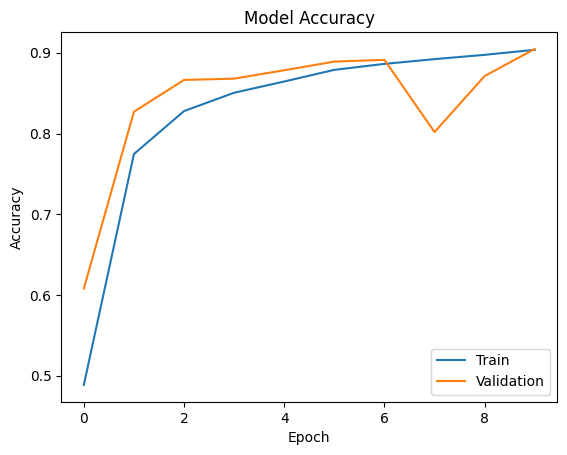

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

662/662 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


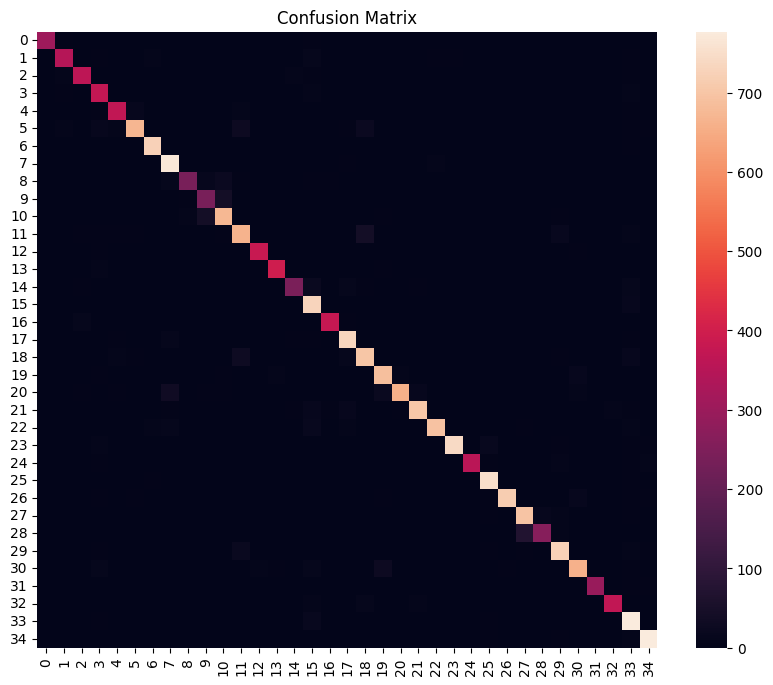

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

pred = model.predict(X_test)

pred = np.argmax(pred,axis=1)

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(10,8))

sns.heatmap(cm)

plt.title("Confusion Matrix")

plt.show()

<Axes: >

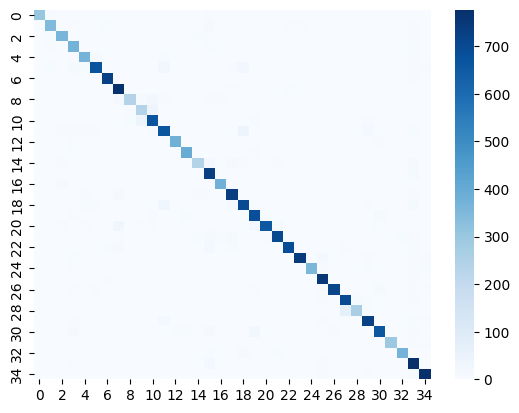

In [13]:
sns.heatmap(cm, cmap="Blues")